In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_curve, auc
import tensorflow as tf
import gc
import optuna
from PIL import Image

import warnings
warnings.filterwarnings('ignore')

I0000 00:00:1779443208.148385     447 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779443208.565806     447 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779443210.032720     447 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# Загрузка и предобработка

In [2]:
from datasets import load_dataset

ds = load_dataset("JJMack/pokemon-classification-gen1-9")

In [3]:
# ================================================================
# Структура
# ================================================================

ds

DatasetDict({
    train: Dataset({
        features: ['file_name', 'image_data', 'label', 'name', 'generation', 'Type 1', 'Type 2', 'HP', 'Attack', 'Defense', 'Sp.Attack', 'Sp.Defense', 'Speed', 'shiny'],
        num_rows: 13188
    })
    validation: Dataset({
        features: ['file_name', 'image_data', 'label', 'name', 'generation', 'Type 1', 'Type 2', 'HP', 'Attack', 'Defense', 'Sp.Attack', 'Sp.Defense', 'Speed', 'shiny'],
        num_rows: 2198
    })
    test: Dataset({
        features: ['file_name', 'image_data', 'label', 'name', 'generation', 'Type 1', 'Type 2', 'HP', 'Attack', 'Defense', 'Sp.Attack', 'Sp.Defense', 'Speed', 'shiny'],
        num_rows: 2530
    })
})

In [4]:
# Зависимая переменная - Type 1

In [5]:
# ================================================================
# Баланс классов
# ================================================================

from collections import Counter

print('train')
counts = Counter(ds['train']['Type 1'])
total = len(ds['train']['Type 1'])
proportions = {k: v / total for k, v in counts.items()}
proportions = {k: round(v, 3) for k, v in proportions.items()}
print(proportions)
print()

print('validation')
counts = Counter(ds['validation']['Type 1'])
total = len(ds['validation']['Type 1'])
proportions = {k: v / total for k, v in counts.items()}
proportions = {k: round(v, 3) for k, v in proportions.items()}
print(proportions)
print()

print('test')
counts = Counter(ds['test']['Type 1'])
total = len(ds['test']['Type 1'])
proportions = {k: v / total for k, v in counts.items()}
proportions = {k: round(v, 3) for k, v in proportions.items()}
print(proportions)

train
{'Grass': 0.095, 'Ground': 0.04, 'Poison': 0.043, 'Water': 0.149, 'Rock': 0.055, 'Steel': 0.029, 'Dragon': 0.034, 'Normal': 0.126, 'Fairy': 0.025, 'Bug': 0.078, 'Electric': 0.056, 'Dark': 0.035, 'Fighting': 0.038, 'Ghost': 0.033, 'Psychic': 0.061, 'Ice': 0.03, 'Fire': 0.07, 'Flying': 0.005}

validation
{'Ground': 0.039, 'Ghost': 0.033, 'Water': 0.152, 'Fire': 0.071, 'Rock': 0.054, 'Poison': 0.041, 'Bug': 0.077, 'Dark': 0.034, 'Psychic': 0.062, 'Ice': 0.031, 'Electric': 0.056, 'Normal': 0.129, 'Fighting': 0.039, 'Fairy': 0.024, 'Grass': 0.093, 'Steel': 0.028, 'Dragon': 0.033, 'Flying': 0.005}

test
{'Grass': 0.1, 'Dark': 0.038, 'Bug': 0.079, 'Rock': 0.057, 'Fire': 0.068, 'Normal': 0.118, 'Fighting': 0.037, 'Ice': 0.03, 'Psychic': 0.059, 'Ghost': 0.031, 'Poison': 0.043, 'Steel': 0.032, 'Water': 0.141, 'Dragon': 0.035, 'Ground': 0.04, 'Flying': 0.006, 'Electric': 0.056, 'Fairy': 0.028}


In [6]:
# ================================================================
# Глобальные константы
# ================================================================

IMG_SIZE = (96, 96)  # 128x128, 96×96, 64×64
BATCH_SIZE = 32
EPOCHS = 20

In [7]:
# Получаем список уникальных классов из тренировочного сплита
unique_types = sorted(list(set(ds['train']['Type 1'])))

# Словарь: Название -> Число
label_to_index = {name: i for i, name in enumerate(unique_types)}

# Словарь: Число -> Название (пригодится для вывода результатов предсказания)
index_to_label = {i: name for name, i in label_to_index.items()}

print("Словарь классов (Mapping):")
print(label_to_index)

Словарь классов (Mapping):
{'Bug': 0, 'Dark': 1, 'Dragon': 2, 'Electric': 3, 'Fairy': 4, 'Fighting': 5, 'Fire': 6, 'Flying': 7, 'Ghost': 8, 'Grass': 9, 'Ground': 10, 'Ice': 11, 'Normal': 12, 'Poison': 13, 'Psychic': 14, 'Rock': 15, 'Steel': 16, 'Water': 17}


In [8]:
# ================================================================
# Функция предобработки
# ================================================================

def preprocess_data(dataset_split):
    images = []
    labels = []

    for item in dataset_split:
        img = item['image_data']

        # Конвертируем текстовую метку в число по нашему словарю
        label_text = item['Type 1']
        label_idx = label_to_index[label_text]

        img = img.convert("RGB").resize(IMG_SIZE)
        img_array = np.array(img) / 255.0

        images.append(img_array)
        labels.append(label_idx)

    return np.array(images), np.array(labels)

In [9]:
%%time
# ================================================================
# Предобработка
# ================================================================

print("Тренировочных данные...")
x_train, y_train = preprocess_data(ds['train'])
print()

print("Валидационные данные...")
x_val, y_val = preprocess_data(ds['validation'])
print()

print("Тестовые данные...")
x_test, y_test = preprocess_data(ds['test'])
print()

print(f"x_train shape: {x_train.shape}, y_train shape: {y_train.shape}")
print(f"x_val shape:   {x_val.shape}, y_val shape:   {y_val.shape}")
print(f"x_test shape:  {x_test.shape}, y_test shape:  {y_test.shape}")

Тренировочных данные...

Валидационные данные...

Тестовые данные...

x_train shape: (13188, 96, 96, 3), y_train shape: (13188,)
x_val shape:   (2198, 96, 96, 3), y_val shape:   (2198,)
x_test shape:  (2530, 96, 96, 3), y_test shape:  (2530,)
CPU times: user 18.9 s, sys: 2.61 s, total: 21.5 s
Wall time: 21.5 s


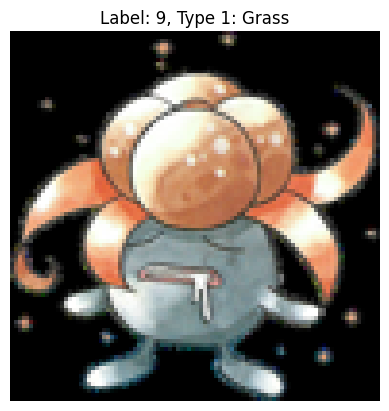

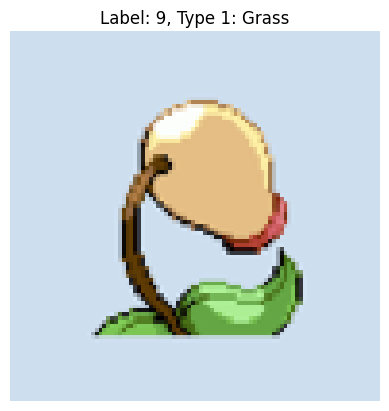

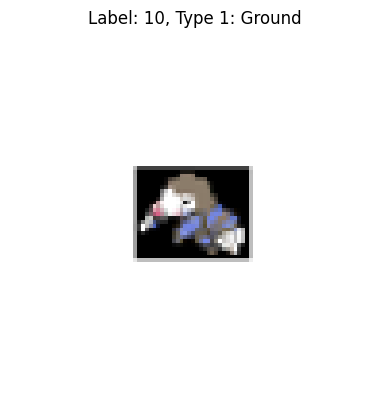

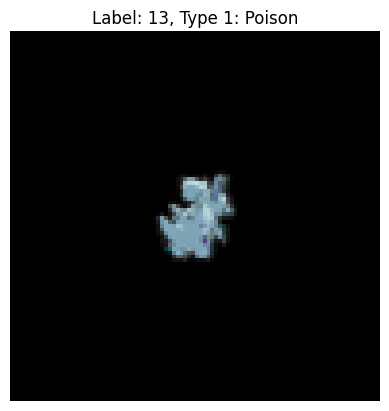

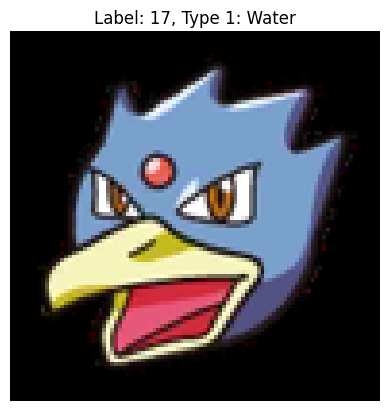

In [10]:
# ================================================================
# Изображения
# ================================================================

for i in range(5):
    plt.imshow(x_train[i])

    # Получаем индекс и название из маппинга
    label_idx = y_train[i]
    label_name = index_to_label[label_idx]

    plt.title(f"Label: {label_idx}, Type 1: {label_name}")
    plt.axis('off')
    plt.show()

In [11]:
print('x_train[0] — это первое изображение целиком')
print(x_train[0])

x_train[0] — это первое изображение целиком
[[[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 ...

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]]


In [12]:
print('x_train[0, 0] — это первая строка пикселей (верхний край) первого изображения')
print(x_train[0, 0])

x_train[0, 0] — это первая строка пикселей (верхний край) первого изображения
[[0.         0.         0.        ]
 [0.         0.         0.        ]
 [0.         0.         0.        ]
 [0.         0.         0.        ]
 [0.         0.         0.        ]
 [0.         0.         0.        ]
 [0.         0.         0.        ]
 [0.         0.         0.        ]
 [0.         0.         0.        ]
 [0.         0.         0.        ]
 [0.         0.         0.        ]
 [0.         0.         0.        ]
 [0.         0.         0.        ]
 [0.         0.         0.        ]
 [0.         0.         0.        ]
 [0.         0.         0.        ]
 [0.         0.         0.        ]
 [0.         0.         0.        ]
 [0.         0.         0.        ]
 [0.         0.         0.        ]
 [0.         0.         0.        ]
 [0.         0.         0.        ]
 [0.         0.         0.        ]
 [0.         0.         0.        ]
 [0.         0.         0.        ]
 [0.         0.       

In [13]:
print('x_train[0, 0, 0] — это один конкретный пиксель (в левом верхнем углу), представленный тремя числами [R, G, B]')
print(x_train[0, 0, 0])

x_train[0, 0, 0] — это один конкретный пиксель (в левом верхнем углу), представленный тремя числами [R, G, B]
[0. 0. 0.]


# Простейшая FCNN

In [14]:
# ================================================================
# Параметры входных данных
# ================================================================

IMG_SHAPE = (96, 96, 3)

# ================================================================
# Модель FCNN
# ================================================================

tf.keras.backend.clear_session()

model = tf.keras.Sequential([
    # 1. Слой преобразования: делает из 3D картинки 1D вектор
    tf.keras.layers.Flatten(input_shape=IMG_SHAPE),

    # 2. Полносвязные слои
    # Увеличим количество нейронов, так как входной вектор стал огромным
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),

    # 3. Выходной слой для бинарной классификации
    tf.keras.layers.Dense(18, activation='softmax')
])

# ================================================================
# Компиляция
# ================================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='sparse_categorical_crossentropy'
)

model.summary()

W0000 00:00:1779443236.871753     447 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1779443236.873873     447 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1779443237.054294     447 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13209 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:02:00.0, compute capability: 12.0a


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 27648)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     7,078,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 18)             │           594 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,097,266 (27.07 MB)

 Trainable params: 7,097,266 (27.07 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
%%time

# ================================================================
# Обучение модели
# ================================================================

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/20


I0000 00:00:1779443240.153387     631 service.cc:153] XLA service 0x7884c0032a80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779443240.153409     631 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1779443240.176354     631 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779443240.270721     631 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1779443240.289883     631 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1504__.12


 85/413 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.0284

I0000 00:00:1779443242.245175     631 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


401/413 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.8702

I0000 00:00:1779443243.067181     630 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1504__.12
I0000 00:00:1779443243.286236     851 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_18', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1779443243.739170     857 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_28', 4 bytes spill stores, 4 bytes spill loads



413/413 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 2.7642 - val_loss: 2.6154
Epoch 2/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.6100 - val_loss: 2.5452
Epoch 3/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.5656 - val_loss: 2.5243
Epoch 4/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.5178 - val_loss: 2.4699
Epoch 5/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.4792 - val_loss: 2.4519
Epoch 6/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.4540 - val_loss: 2.4813
Epoch 7/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.4153 - val_loss: 2.4269
Epoch 8/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.3766 - val_loss: 2.4049
Epoch 9/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.3403 - val_loss: 2.4206
Epoch 10/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.3062 - val_loss: 2.3901
Epoch 11/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.2663 - val_loss: 2.3881
Epoch 12/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2

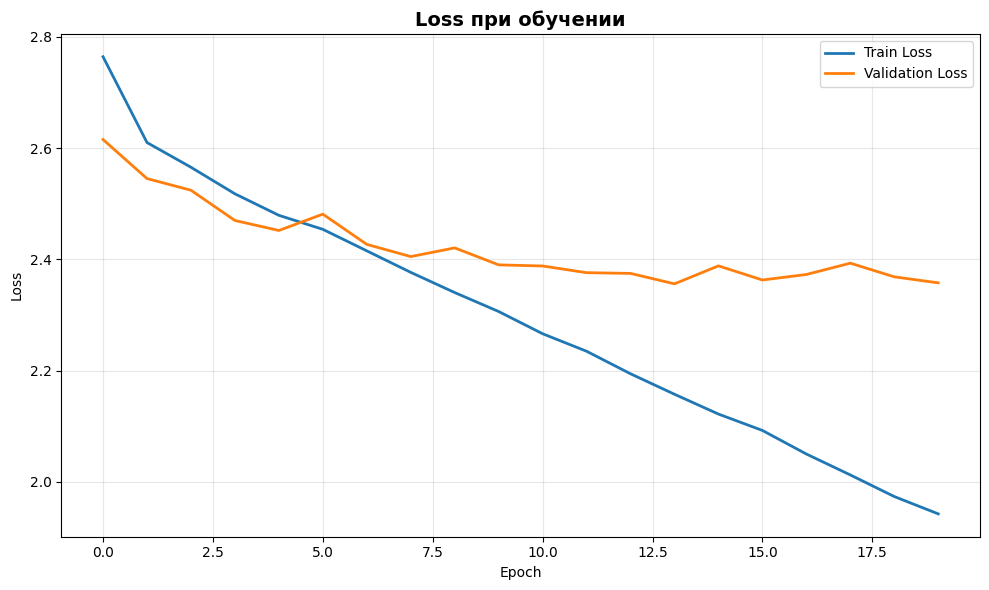

In [16]:
# ================================================================
# Визуализация процесса обучения
# ================================================================

plt.figure(figsize=(10, 6))

# График потерь (Loss)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Loss при обучении', fontweight='bold', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# ================================================================
# Прогноз на тестовой выборке
# ================================================================

y_pred = model.predict(x_test, verbose=1, batch_size=BATCH_SIZE)

y_pred_classes = y_pred.argmax(axis=-1).astype("int32")

80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [18]:
# ================================================================
# Метрики ошибок на тестовой выборке
# ================================================================

print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.26      0.12      0.16       200
           1       0.14      0.15      0.14        97
           2       0.12      0.01      0.02        89
           3       0.23      0.25      0.24       142
           4       0.67      0.14      0.24        70
           5       0.26      0.08      0.12        93
           6       0.39      0.52      0.45       173
           7       0.00      0.00      0.00        15
           8       0.13      0.04      0.06        79
           9       0.42      0.49      0.45       254
          10       0.50      0.01      0.02       102
          11       0.33      0.08      0.13        76
          12       0.22      0.53      0.31       299
          13       0.31      0.25      0.28       110
          14       0.33      0.30      0.31       149
          15       0.15      0.08      0.10       144
          16       0.33      0.07      0.12        81
          17       0.34    

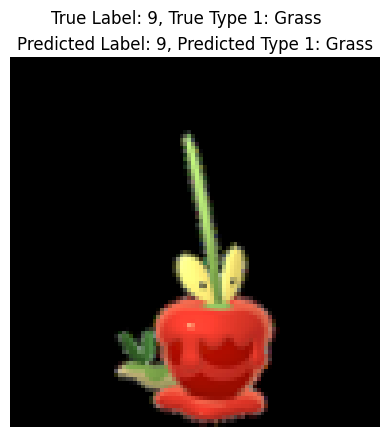

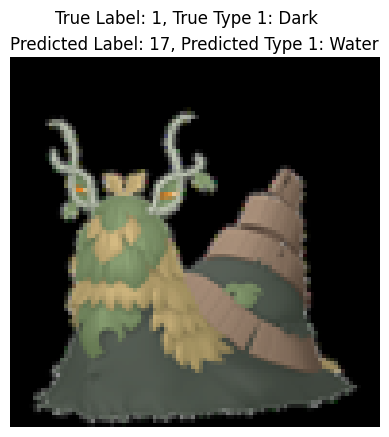

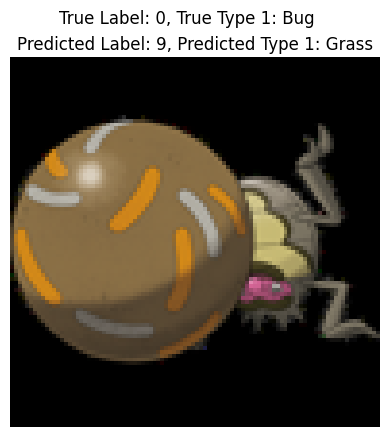

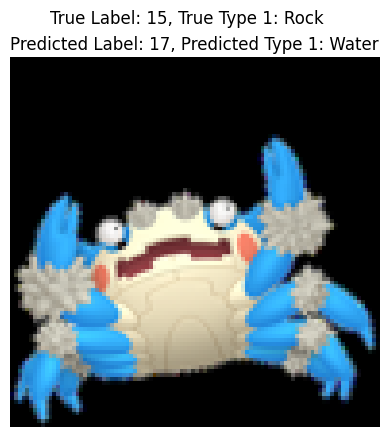

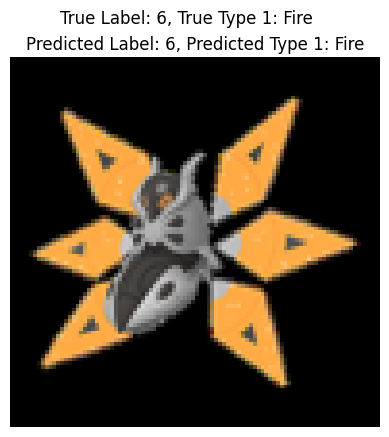

In [19]:
# ================================================================
# Изображения
# ================================================================

for i in range(5):
    plt.imshow(x_test[i])

    # Получаем индекс и название из маппинга
    label_idx = y_test[i]
    label_name = index_to_label[label_idx]

    predicated_label_idx = y_pred_classes[i]
    predicated_label_name = index_to_label[predicated_label_idx]

    plt.suptitle(f"True Label: {label_idx}, True Type 1: {label_name}")
    plt.title(f"Predicted Label: {predicated_label_idx}, Predicted Type 1: {predicated_label_name}")
    plt.axis('off')
    plt.show()

# Простейшая CNN

In [20]:
# ================================================================
# Параметры из нашей предобработки
# ================================================================

IMG_HEIGHT, IMG_WIDTH = 96, 96
CHANNELS = 3

# ================================================================
# Модель CNN
# ================================================================

tf.keras.backend.clear_session()

model = tf.keras.Sequential([
    # 1. Входной слой (ожидает картинку 96x96x3)
    tf.keras.layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS)),

    # 2. Сверточный блок 1: ищем простые признаки (границы, углы)
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    # 3. Сверточный блок 2: ищем более сложные формы
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    # 4. Сверточный блок 3: глубокие признаки
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    # 5. Превращаем 2D признаки в одномерный вектор
    tf.keras.layers.Flatten(),

    # 6. Полносвязные слои (теперь они работают с признаками из картинок)
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5), # Защита от переобучения
    tf.keras.layers.Dense(32, activation='relu'),

    # 7. Выходной слой
    tf.keras.layers.Dense(18, activation='softmax')
])

# ================================================================
# Компиляция
# ================================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='sparse_categorical_crossentropy'
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       819,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 18)             │           594 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 915,186 (3.49 MB)

 Trainable params: 915,186 (3.49 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
%%time

# ================================================================
# Обучение модели
# ================================================================

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/20


I0000 00:00:1779443269.992915     628 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_33834__.38
I0000 00:00:1779443271.320340    3083 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_8', 4 bytes spill stores, 4 bytes spill loads



399/413 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.7718

I0000 00:00:1779443274.387699     631 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_33834__.38
I0000 00:00:1779443274.827880    3269 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_12', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1779443274.905537    3275 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_12', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1779443275.032409    3280 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_22', 4 bytes spill stores, 4 bytes spill loads



413/413 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 2.6990 - val_loss: 2.5451
Epoch 2/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 2.5710 - val_loss: 2.5015
Epoch 3/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 2.5122 - val_loss: 2.4024
Epoch 4/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 2.4638 - val_loss: 2.3746
Epoch 5/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 2.4125 - val_loss: 2.3421
Epoch 6/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 2.3490 - val_loss: 2.3074
Epoch 7/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 2.2899 - val_loss: 2.2419
Epoch 8/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 2.2301 - val_loss: 2.2013
Epoch 9/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 2.1781 - val_loss: 2.1665
Epoch 10/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 2.1156 - val_loss: 2.1413
Epoch 11/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 2.0503 - val_loss: 2.0928
Epoch 12/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 

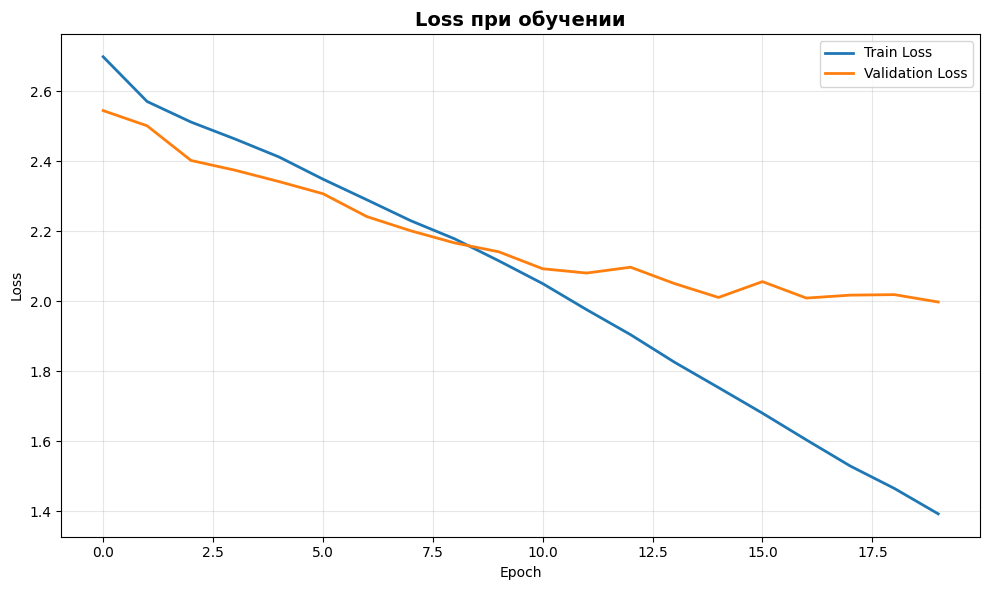

In [22]:
# ================================================================
# Визуализация процесса обучения
# ================================================================

plt.figure(figsize=(10, 6))

# График потерь (Loss)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Loss при обучении', fontweight='bold', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# ================================================================
# Прогноз на тестовой выборке
# ================================================================

y_pred = model.predict(x_test, verbose=1, batch_size=BATCH_SIZE)

y_pred_classes = y_pred.argmax(axis=-1).astype("int32")

72/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

I0000 00:00:1779443311.200299    5367 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_6', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1779443311.261908    5366 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_6', 8 bytes spill stores, 8 bytes spill loads



80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [24]:
# ================================================================
# Метрики ошибок на тестовой выборке
# ================================================================

print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.37      0.35      0.36       200
           1       0.37      0.33      0.35        97
           2       0.44      0.24      0.31        89
           3       0.47      0.37      0.41       142
           4       0.60      0.26      0.36        70
           5       0.40      0.18      0.25        93
           6       0.52      0.64      0.57       173
           7       0.00      0.00      0.00        15
           8       0.29      0.25      0.27        79
           9       0.63      0.67      0.65       254
          10       0.32      0.19      0.23       102
          11       0.42      0.13      0.20        76
          12       0.40      0.63      0.49       299
          13       0.40      0.32      0.35       110
          14       0.37      0.32      0.34       149
          15       0.26      0.21      0.23       144
          16       0.42      0.22      0.29        81
          17       0.41    

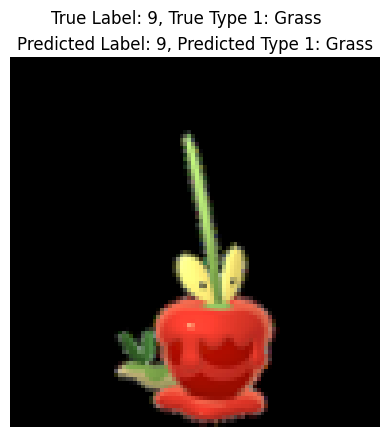

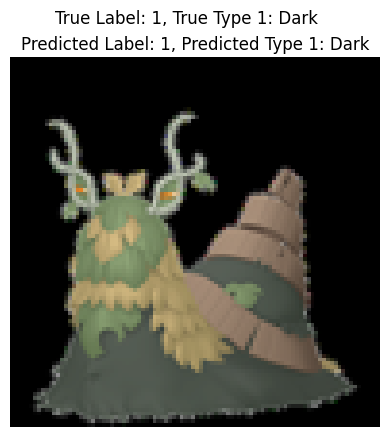

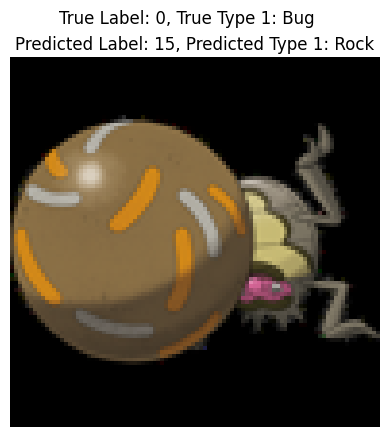

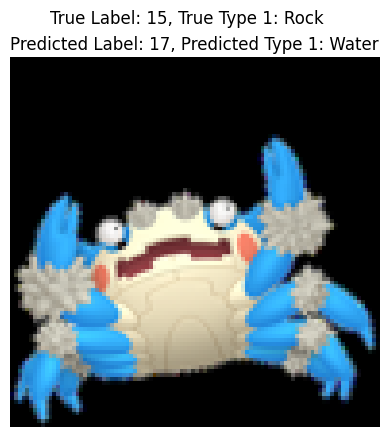

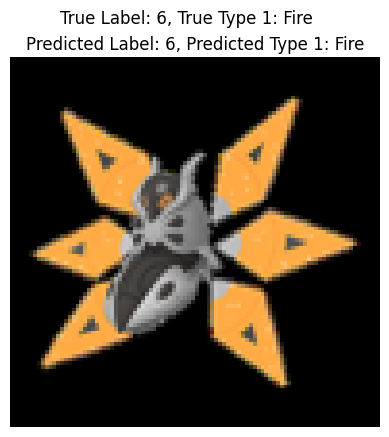

In [25]:
# ================================================================
# Изображения
# ================================================================

for i in range(5):
    plt.imshow(x_test[i])

    # Получаем индекс и название из маппинга
    label_idx = y_test[i]
    label_name = index_to_label[label_idx]

    predicated_label_idx = y_pred_classes[i]
    predicated_label_name = index_to_label[predicated_label_idx]

    plt.suptitle(f"True Label: {label_idx}, True Type 1: {label_name}")
    plt.title(f"Predicted Label: {predicated_label_idx}, Predicted Type 1: {predicated_label_name}")
    plt.axis('off')
    plt.show()

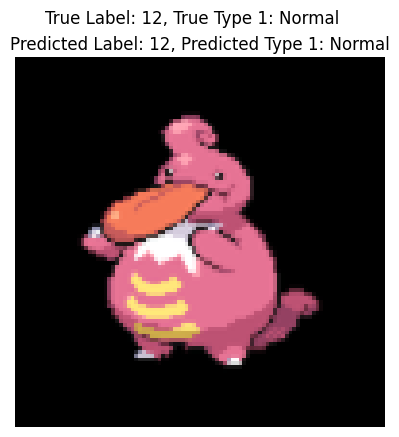

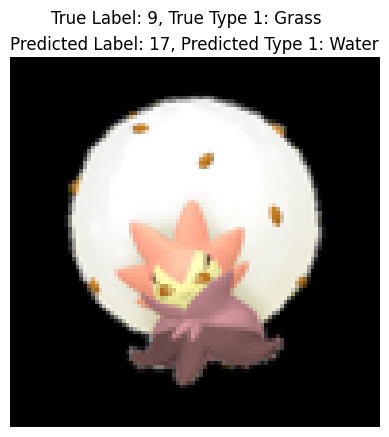

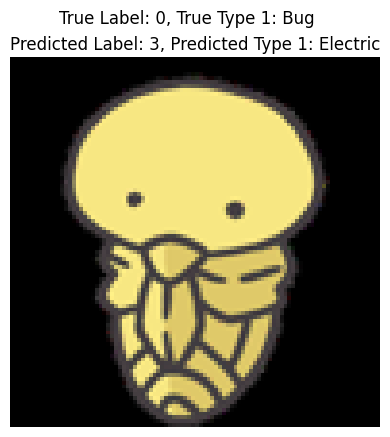

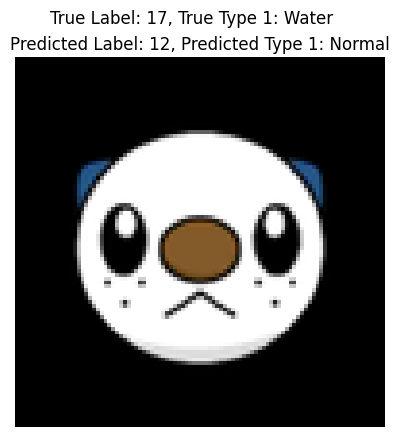

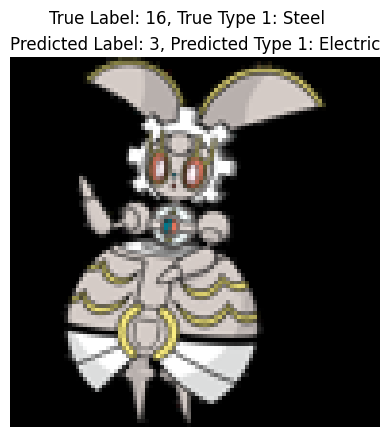

In [26]:
# ================================================================
# Изображения
# ================================================================

for i in range(5):
    plt.imshow(x_test[i+1000])

    # Получаем индекс и название из маппинга
    label_idx = y_test[i+1000]
    label_name = index_to_label[label_idx]

    predicated_label_idx = y_pred_classes[i+1000]
    predicated_label_name = index_to_label[predicated_label_idx]

    plt.suptitle(f"True Label: {label_idx}, True Type 1: {label_name}")
    plt.title(f"Predicted Label: {predicated_label_idx}, Predicted Type 1: {predicated_label_name}")
    plt.axis('off')
    plt.show()

# Тюнинг CNN

In [27]:
def cnn_model(
    x_train,
    y_train,
    x_val=None,
    y_val=None,
    conv_layers=3,     # Количество сверточных блоков
    filters=32,        # Начальное количество фильтров
    n_units=64,        # Нейроны в полносвязном слое
    learning_rate=3e-4,
    batch_size=32,
    dropout=0.3,
    epochs=10,
    patience=5,
    verbose=1
):

    # ================================================================
    # 1. Создание модели
    # ================================================================
    model = tf.keras.Sequential()

    # Входной слой (96, 96, 3)
    model.add(tf.keras.layers.Input(shape=(x_train.shape[1], x_train.shape[2], x_train.shape[3])))

    # Сверточный блок (циклом)
    for i in range(conv_layers):
        # Увеличиваем количество фильтров с глубиной (например, 32 -> 64 -> 128)
        model.add(tf.keras.layers.Conv2D(filters * (2**i), (3, 3), activation='relu', padding='same'))
        model.add(tf.keras.layers.BatchNormalization()) # Стабилизация обучения
        model.add(tf.keras.layers.MaxPooling2D((2, 2)))

    # Переход от карт признаков к вектору
    model.add(tf.keras.layers.Flatten())

    # Полносвязный блок (Dense)
    model.add(tf.keras.layers.Dense(n_units, activation='relu'))
    if dropout > 0:
        model.add(tf.keras.layers.Dropout(dropout))

    # Выходной слой.
    model.add(tf.keras.layers.Dense(18, activation='softmax'))

    # ================================================================
    # 2. Компиляция
    # ================================================================
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy'
    )

    # ================================================================
    # 3. Callbacks & Обучение
    # ================================================================
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss' if x_val is not None else 'loss',
            patience=patience,
            restore_best_weights=True,
            verbose=verbose
        )
    ]

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val) if x_val is not None else None,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=verbose
    )

    return model, history.history

In [28]:
def objective(trial):

    conv_layers = trial.suggest_int('conv_layers', 1, 5, step=1) # 1. Количество сверточных слоев (блоков) - обычно от 2 до 5
    filters = trial.suggest_int('filters', 16, 64, step=16) # 2. Начальное количество фильтров (степень двойки: 16, 32, 64)
    n_units = trial.suggest_int('n_units', 32, 256, step=32) # 3. Количество нейронов в полносвязном (Dense) слое
    dropout = trial.suggest_float('dropout', 0, 0.5, step=0.1) # 4. Вероятность Dropout (от 0.1 до 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True) # 5. Скорость обучения

    model, history = cnn_model(
        x_train=x_train,
        y_train=y_train,
        x_val=x_val,
        y_val=y_val,
        conv_layers=conv_layers,
        filters=filters,
        n_units=n_units,
        learning_rate=learning_rate,
        batch_size=BATCH_SIZE,
        dropout=dropout,
        epochs=EPOCHS,
        patience=5,
        verbose=0
    )

    y_pred = model.predict(x_val, batch_size=BATCH_SIZE, verbose=0)

    y_pred_classes = y_pred.argmax(axis=-1).astype("int32")

    score = f1_score(y_val, y_pred_classes, average='macro')

    del model, history, y_pred, y_pred_classes

    gc.collect()
    tf.keras.backend.clear_session()

    return score

In [29]:
sampler = optuna.samplers.TPESampler(
    n_startup_trials=5,
    multivariate=True,
    group=True,
    constant_liar=True
)

study = optuna.create_study(direction='maximize', sampler=sampler)

[I 2026-05-22 14:48:31,850] A new study created in memory with name: no-name-a6ba81ff-08d2-4959-92da-40865f4862a2


In [30]:
study.optimize(
    objective,
    n_trials=50,
    show_progress_bar=True,
    gc_after_trial=True,
    n_jobs=1
)

  0%|          | 0/50 [00:00<?, ?it/s]

I0000 00:00:1779443314.101600     630 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_67321__.53
I0000 00:00:1779443314.453075     630 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1779443314.757218    5506 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 96 bytes spill stores, 96 bytes spill loads

I0000 00:00:1779443315.390641     630 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1779443315.627170    5499 subprocess_compilation.cc:348] ptxas warning : Registers are spille

[I 2026-05-22 14:49:05,691] Trial 0 finished with value: 0.38314339857289403 and parameters: {'conv_layers': 3, 'filters': 32, 'n_units': 192, 'dropout': 0.1, 'learning_rate': 0.00016270637510913154}. Best is trial 0 with value: 0.38314339857289403.


I0000 00:00:1779443348.193726     627 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_88929__.68
I0000 00:00:1779443352.400554     631 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_88929__.68
I0000 00:00:1779443352.569809    7443 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_14', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1779443352.863613    7451 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1779443352.878165    7449 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 8 bytes spill stores, 8 bytes spill loads



[I 2026-05-22 14:49:57,035] Trial 1 finished with value: 0.05945771912330164 and parameters: {'conv_layers': 4, 'filters': 32, 'n_units': 64, 'dropout': 0.30000000000000004, 'learning_rate': 0.00050489235494185}. Best is trial 0 with value: 0.38314339857289403.


...

[I 2026-05-22 15:35:03,689] Trial 47 finished with value: 0.49127311629667275 and parameters: {'conv_layers': 5, 'filters': 64, 'n_units': 256, 'dropout': 0.0, 'learning_rate': 0.00045017247404044214}. Best is trial 41 with value: 0.5180295326811414.


I0000 00:00:1779446106.451036     627 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1342513__.52
I0000 00:00:1779446111.367487     627 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1342513__.52
I0000 00:00:1779446111.508320  106612 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_14', 4 bytes spill stores, 4 bytes spill loads



[I 2026-05-22 15:36:03,067] Trial 48 finished with value: 0.22228606407791154 and parameters: {'conv_layers': 3, 'filters': 64, 'n_units': 256, 'dropout': 0.0, 'learning_rate': 0.0004487277485126149}. Best is trial 41 with value: 0.5180295326811414.


I0000 00:00:1779446166.663711     625 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1367681__.82
I0000 00:00:1779446171.665899     629 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1367681__.82


[I 2026-05-22 15:36:57,906] Trial 49 finished with value: 0.36494429306768533 and parameters: {'conv_layers': 5, 'filters': 48, 'n_units': 256, 'dropout': 0.0, 'learning_rate': 0.0005733333751123227}. Best is trial 41 with value: 0.5180295326811414.


In [31]:
trials_df = study.trials_dataframe()
trials_df = trials_df.sort_values('value', ascending=False)
trials_df.to_csv('tuning.csv')
trials_df

,number,value,datetime_start,datetime_complete,duration,params_conv_layers,params_dropout,params_filters,params_learning_rate,params_n_units,system_attrs_tpe:relative_params:0,state
41,41,0.518030,2026-05-22 15:28:31.125825,2026-05-22 15:29:28.278184,0 days 00:00:57.152359,5,0.0,48,0.000204,256,"{""conv_layers"": 5, ""dropout"": 0.0, ""filters"": ...",COMPLETE
46,46,0.507268,2026-05-22 15:32:52.356735,2026-05-22 15:33:44.196466,0 days 00:00:51.839731,5,0.0,48,0.000222,256,"{""conv_layers"": 5, ""dropout"": 0.0, ""filters"": ...",COMPLETE
29,29,0.505880,2026-05-22 15:14:05.498792,2026-05-22 15:15:24.206281,0 days 00:01:18.707489,5,0.1,64,0.000221,160,"{""conv_layers"": 5, ""dropout"": 0.1, ""filters"": ...",COMPLETE
39,39,0.501598,2026-05-22 15:26:58.581170,2026-05-22 15:27:53.609146,0 days 00:00:55.027976,5,0.0,48,0.000192,192,"{""conv_layers"": 5, ""dropout"": 0.0, ""filters"": ...",COMPLETE
47,47,0.491273,2026-05-22 15:33:44.709559,2026-05-22 15:35:03.689502,0 days 00:01:18.979943,5,0.0,64,0.000450,256,"{""conv_layers"": 5, ""dropout"": 0.0, ""filters"": ...",COMPLETE
30,30,0.490043,2026-05-22 15:15:24.546077,2026-05-22 15:16:54.406009,0 days 00:01:29.859932,5,0.2,64,0.000218,192,"{""conv_layers"": 5, ""dropout"": 0.2, ""filters"": ...",COMPLETE
42,42,0.485196,2026-05-22 15:29:28.734526,2026-05-22 15:30:22.308373,0 days 00:00:53.573847,5,0.0,48,0.000123,256,"{""conv_layers"": 5, ""dropout"": 0.0, ""filters"": ...",COMPLETE
31,31,0.480238,2026-05-22 15:16:54.760921,2026-05-22 15:18:06.109327,0 days 00:01:11.348406,5,0.1,64,0.000082,192,"{""conv_layers"": 5, ""dropout"": 0.1, ""filters"": ...",COMPLETE
24,24,0.479074,2026-05-22 15:09:34.763254,2026-05-22 15:10:37.124038,0 days 00:01:02.360784,5,0.0,48,0.000314,128,"{""conv_layers"": 5, ""dropout"": 0.0, ""filters"": ...",COMPLETE
32,32,0.464024,2026-05-22 15:18:06.473158,2026-05-22 15:19:21.972225,0 days 00:01:15.499067,5,0.2,64,0.000143,192,"{""conv_layers"": 5, ""dropout"": 0.2, ""filters"": ...",COMPLETE


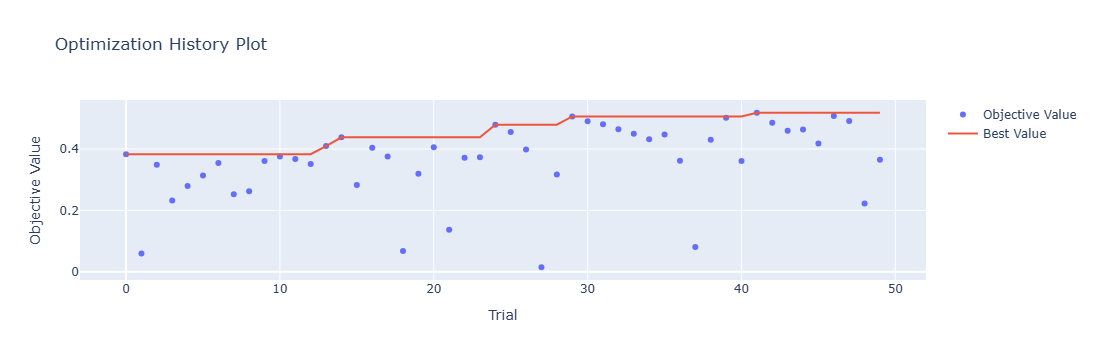

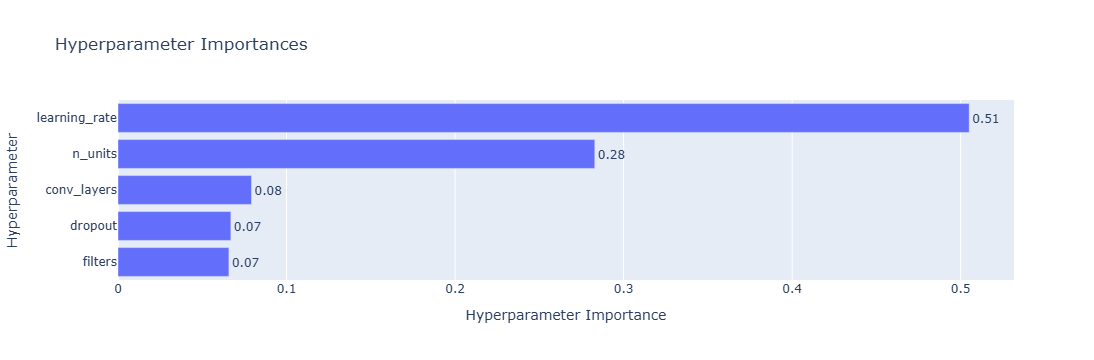

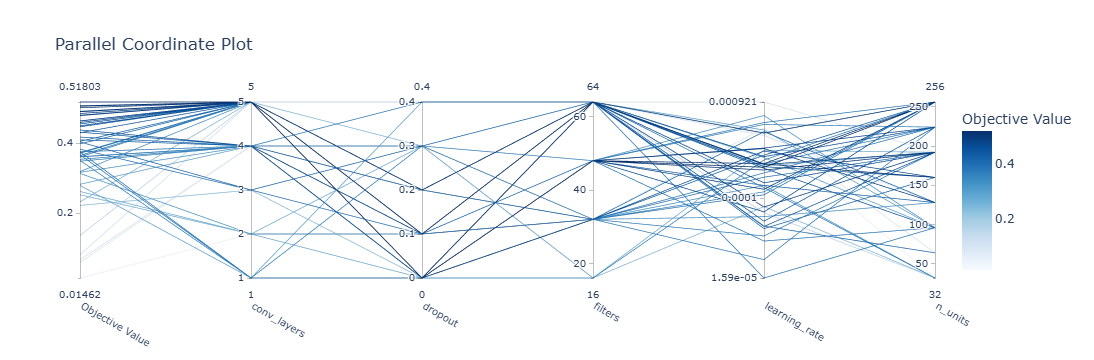

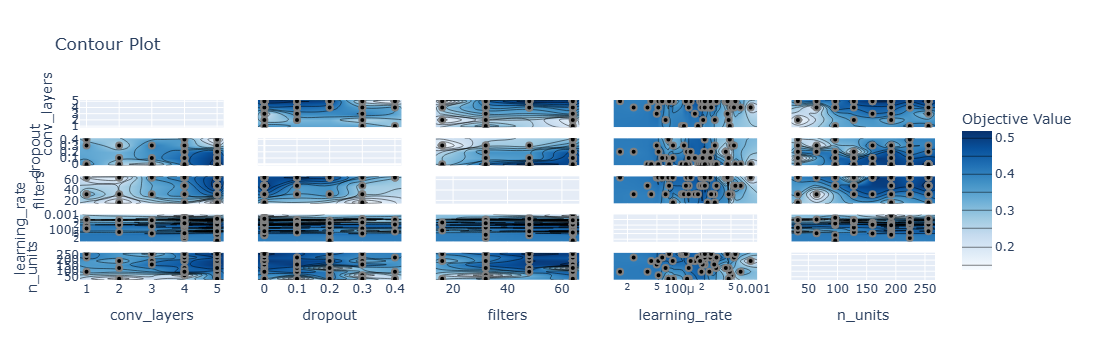

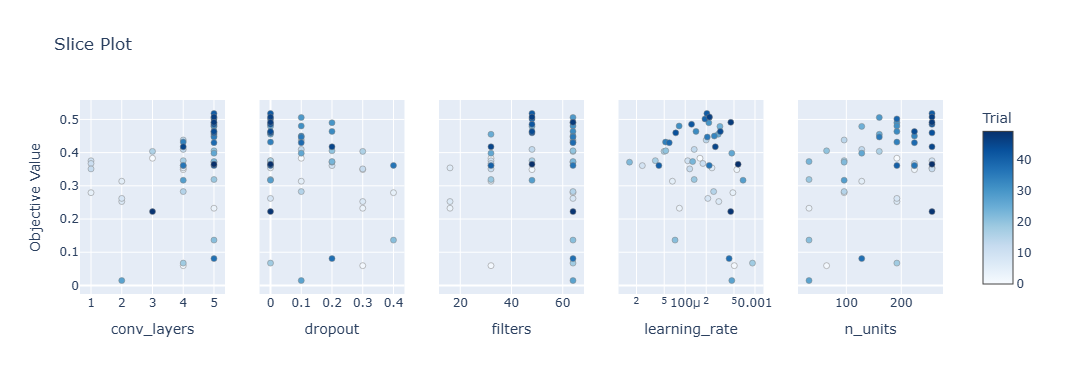

In [32]:
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_parallel_coordinate, plot_contour, plot_slice

plot_optimization_history(study).show()
plot_param_importances(study).show()
plot_parallel_coordinate(study).show()
plot_contour(study).show()
plot_slice(study).show()

In [33]:
print("Лучшие параметры:", study.best_params)
print("Лучший value:", study.best_value)

Лучшие параметры: {'conv_layers': 5, 'filters': 48, 'n_units': 256, 'dropout': 0.0, 'learning_rate': 0.00020439449096095854}
Лучший value: 0.5180295326811414


# Обучение модели с наилучшей конфигурацией гиперпараметров

In [34]:
CONV_LAYERS = 5
FILTERS = 64
N_UNITS = 256
DROPOUT = 0
LEARNING_RATE = 0.00020439449096095854

In [35]:
model, history = cnn_model(
    x_train=x_train,
    y_train=y_train,
    x_val=x_val,
    y_val=y_val,
    conv_layers=CONV_LAYERS,
    filters=FILTERS,
    n_units=N_UNITS,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    dropout=DROPOUT,
    epochs=EPOCHS,
    patience=5,
    verbose=1
)

Epoch 1/20


I0000 00:00:1779447529.998755     625 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1393455__.82


411/413 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.9408

I0000 00:00:1779447536.148063     625 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1393455__.82


413/413 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 2.6173 - val_loss: 3.2596
Epoch 2/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 2.3022 - val_loss: 2.3528
Epoch 3/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 2.0644 - val_loss: 2.1918
Epoch 4/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 1.7701 - val_loss: 1.9755
Epoch 5/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 1.3484 - val_loss: 1.8523
Epoch 6/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.8129 - val_loss: 1.8341
Epoch 7/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.3831 - val_loss: 1.6597
Epoch 8/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.1570 - val_loss: 1.7208
Epoch 9/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0923 - val_loss: 1.8199
Epoch 10/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0847 - val_loss: 1.7322
Epoch 11/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0520 - val_loss: 1.8571
Epoch 12/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/st

In [36]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 1024)     │     4,719,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 6, 6, 1024)     │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 3, 3, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 18)             │         4,626 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,920,184 (98.88 MB)

 Trainable params: 8,638,738 (32.95 MB)

 Non-trainable params: 3,968 (15.50 KB)

 Optimizer params: 17,277,478 (65.91 MB)

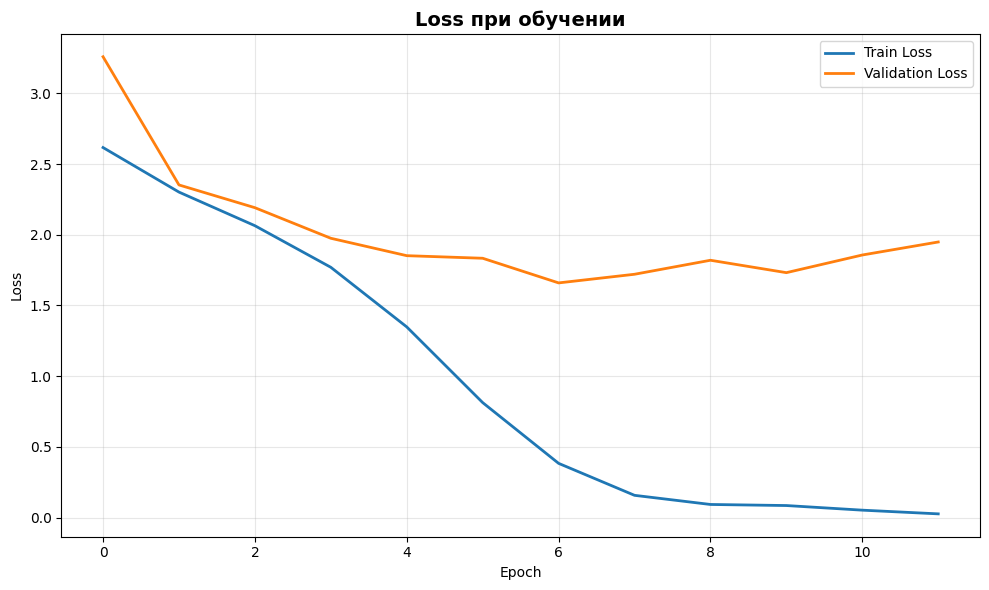

In [37]:
# ================================================================
# Визуализация процесса обучения
# ================================================================

plt.figure(figsize=(10, 6))

# График потерь (Loss)
plt.plot(history['loss'], label='Train Loss', linewidth=2)
plt.plot(history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Loss при обучении', fontweight='bold', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
# ================================================================
# Прогноз на тестовой выборке
# ================================================================

y_pred = model.predict(x_test, verbose=1, batch_size=BATCH_SIZE)

y_pred_classes = y_pred.argmax(axis=-1).astype("int32")

80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


In [39]:
# ================================================================
# Метрики ошибок на тестовой выборке
# ================================================================

print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.44      0.57      0.50       200
           1       0.58      0.38      0.46        97
           2       0.35      0.42      0.38        89
           3       0.74      0.32      0.44       142
           4       0.61      0.39      0.47        70
           5       0.64      0.51      0.56        93
           6       0.74      0.51      0.60       173
           7       0.67      0.13      0.22        15
           8       0.58      0.48      0.53        79
           9       0.67      0.63      0.65       254
          10       0.38      0.49      0.43       102
          11       0.57      0.46      0.51        76
          12       0.50      0.70      0.58       299
          13       0.53      0.47      0.50       110
          14       0.44      0.55      0.49       149
          15       0.62      0.40      0.49       144
          16       0.52      0.44      0.48        81
          17       0.55    

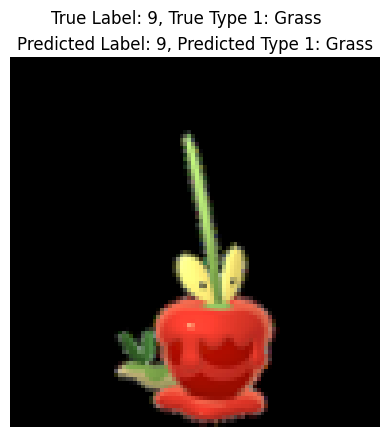

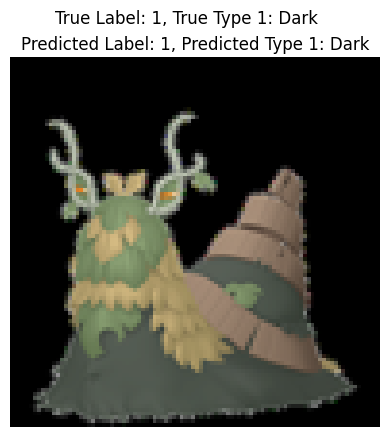

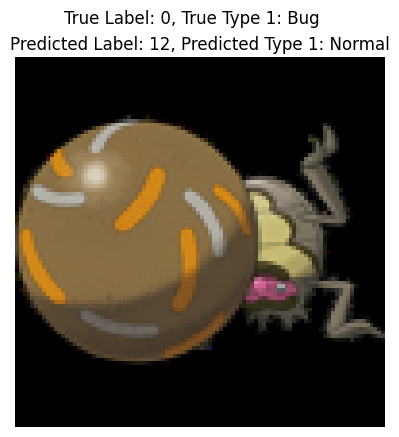

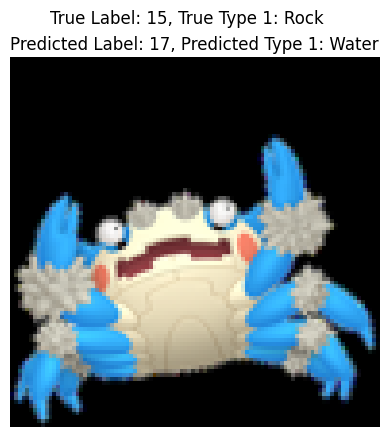

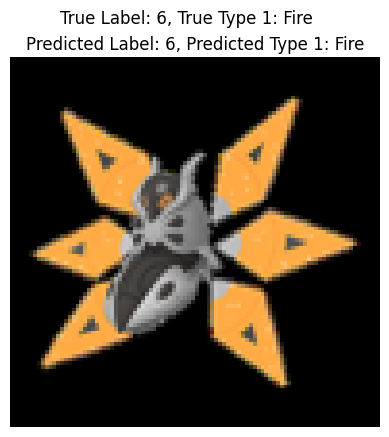

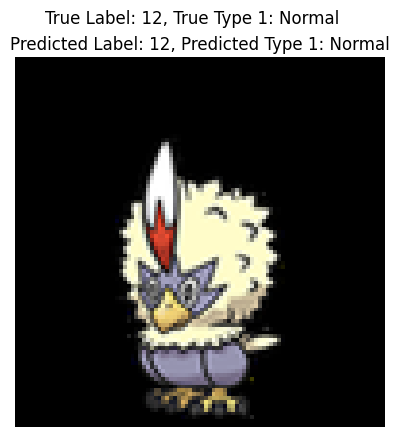

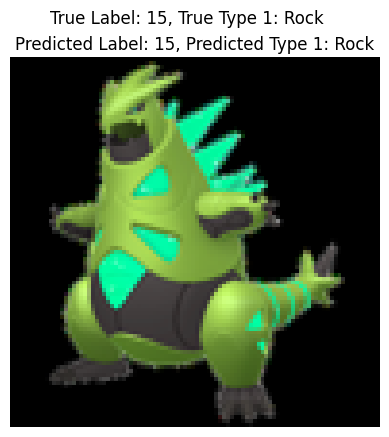

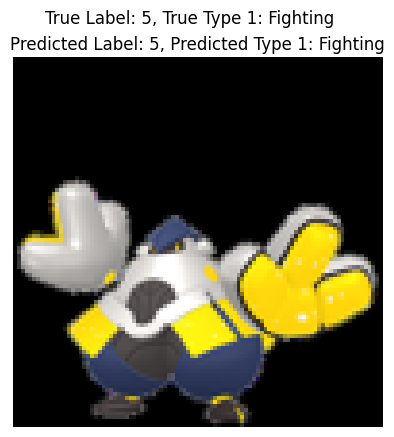

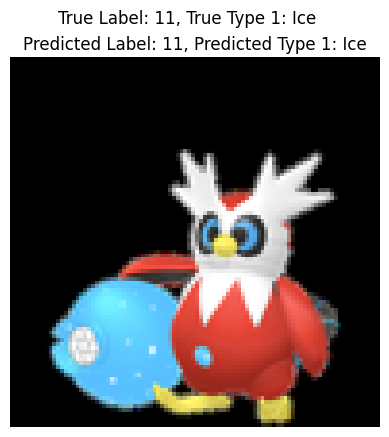

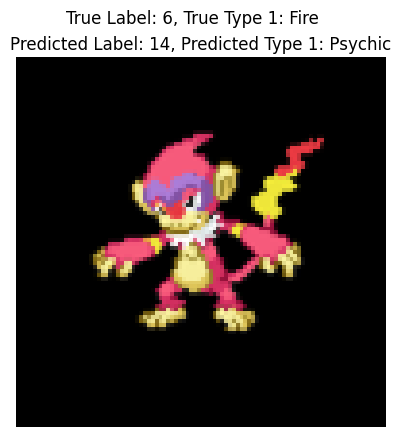

In [40]:
# ================================================================
# Изображения
# ================================================================

for i in range(10):
    plt.imshow(x_test[i])

    # Получаем индекс и название из маппинга
    label_idx = y_test[i]
    label_name = index_to_label[label_idx]

    predicated_label_idx = y_pred_classes[i]
    predicated_label_name = index_to_label[predicated_label_idx]

    plt.suptitle(f"True Label: {label_idx}, True Type 1: {label_name}")
    plt.title(f"Predicted Label: {predicated_label_idx}, Predicted Type 1: {predicated_label_name}")
    plt.axis('off')
    plt.show()

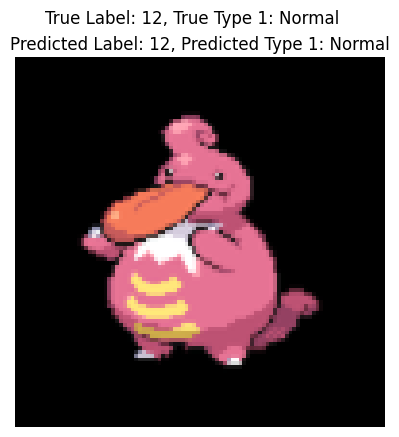

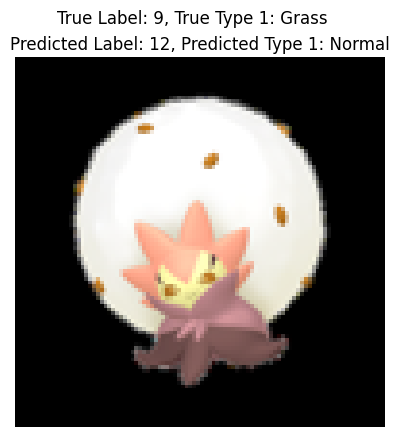

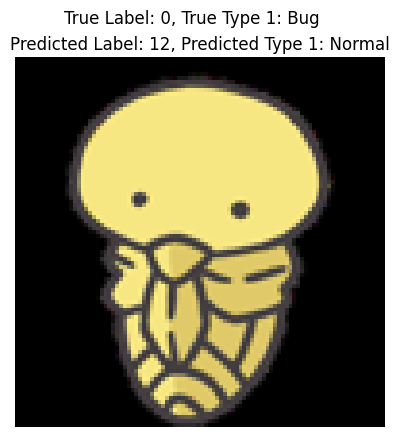

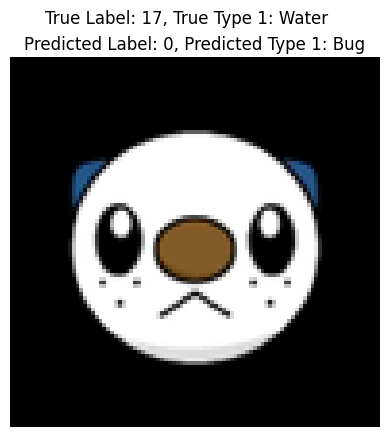

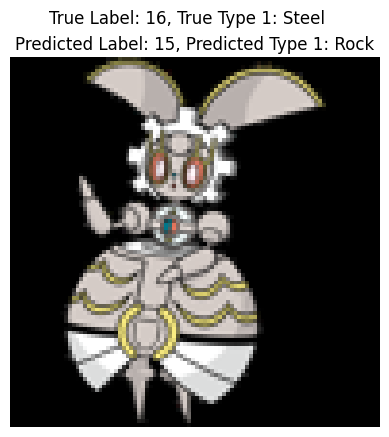

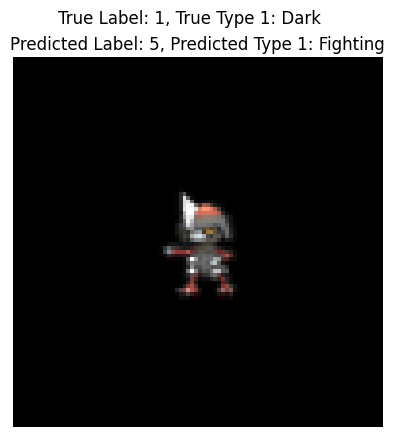

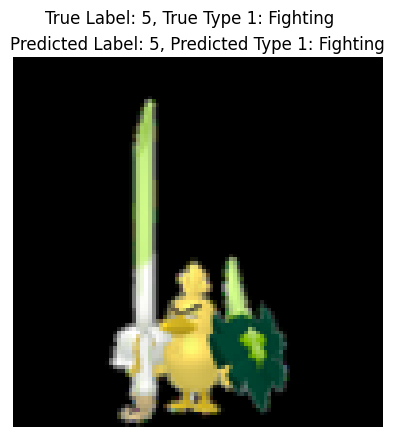

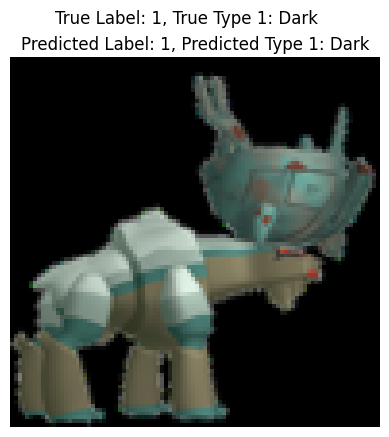

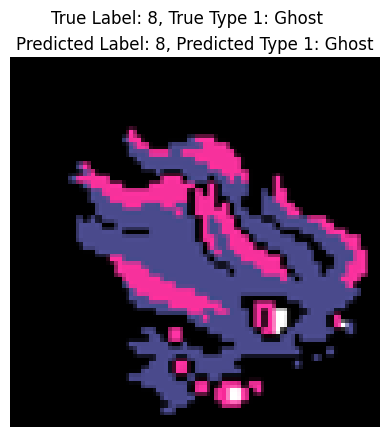

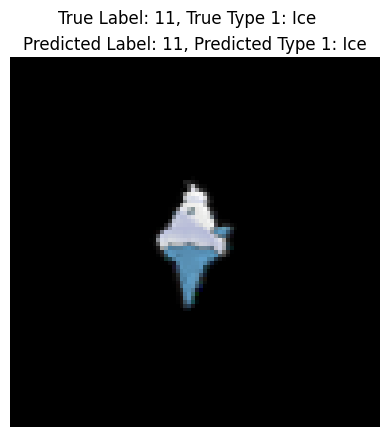

In [41]:
# ================================================================
# Изображения
# ================================================================

for i in range(10):
    plt.imshow(x_test[i+1000])

    # Получаем индекс и название из маппинга
    label_idx = y_test[i+1000]
    label_name = index_to_label[label_idx]

    predicated_label_idx = y_pred_classes[i+1000]
    predicated_label_name = index_to_label[predicated_label_idx]

    plt.suptitle(f"True Label: {label_idx}, True Type 1: {label_name}")
    plt.title(f"Predicted Label: {predicated_label_idx}, Predicted Type 1: {predicated_label_name}")
    plt.axis('off')
    plt.show()